In [31]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import matplotlib.pyplot as plt

## Preparing Dataset

In [7]:
dataset_path = "/content/drive/MyDrive/7-7-Faces"
width = height = 224

image_data_generator = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    brightness_range=(0.8,1.2),
    validation_split=0.1
)

train_data = image_data_generator.flow_from_directory(
    dataset_path,
    target_size=(width,height),
    subset="training",
    shuffle=True,
    batch_size=32
)

validation_data = image_data_generator.flow_from_directory(
    dataset_path,
    target_size=(width,height),
    subset="validation",
    shuffle=False,
    batch_size=32
)

Found 1227 images belonging to 14 classes.
Found 131 images belonging to 14 classes.


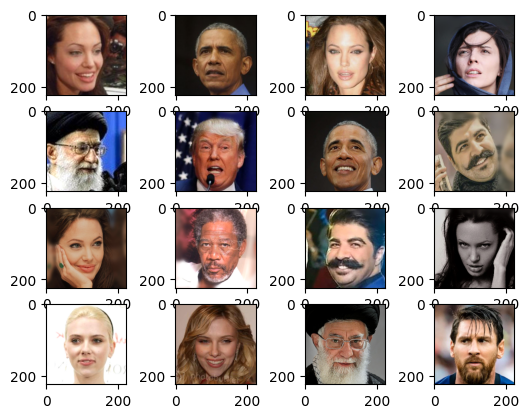

In [21]:
train_image = next(train_data)[0]

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(train_image[i])


## Create Model

In [33]:
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet", # Transfer leraning
    input_shape=(width,height,3),
    pooling="avg"
)

In [34]:
for layer in base_model.layers[:-4]:
    layer.trainable = False

In [ ]:
base_model.summary()

In [37]:
model = Sequential([
    base_model,
    layers.Dense(14,activation="softmax")
])

In [ ]:
model.summary()

In [42]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=RMSprop(learning_rate=1e-4), #0.001
    metrics=["accuracy"]
)

In [43]:
history = model.fit(train_data,
                    validation_data=validation_data,
                    epochs=32)

Epoch 1/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 551s 14s/step - accuracy: 0.4206 - loss: 1.9543 - val_accuracy: 0.5420 - val_loss: 1.4631
Epoch 2/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 327ms/step - accuracy: 0.8202 - loss: 0.8576 - val_accuracy: 0.6794 - val_loss: 1.0775
Epoch 3/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 334ms/step - accuracy: 0.9037 - loss: 0.5130 - val_accuracy: 0.7328 - val_loss: 0.8750
Epoch 4/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 334ms/step - accuracy: 0.9306 - loss: 0.3824 - val_accuracy: 0.7176 - val_loss: 0.8390
Epoch 5/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 323ms/step - accuracy: 0.9592 - loss: 0.2677 - val_accuracy: 0.7481 - val_loss: 0.7421
Epoch 6/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 329ms/step - accuracy: 0.9635 - loss: 0.2024 - val_accuracy: 0.7481 - val_loss: 0.7430
Epoch 7/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 328ms/step - accuracy: 0.9846 - loss: 0.1603 - val_accuracy: 0.7710 - val_loss: 0.6868
Epoch 8/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 333ms/step - accuracy: 0.9855 - loss: 0.1215 - val_accur